### Imports

In [2]:
import os
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.distributions import Categorical, Normal
from dataclasses import dataclass

### Helpers

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

os.makedirs("checkpoints", exist_ok=True)

Using device: cuda


### Moving Average and Confidence Interval Utilities

In [4]:
def moving_average(data, window_size=25):
    data = np.asarray(data, dtype=np.float64)

    if len(data) < window_size:
        return data

    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode="valid")


def mean_and_95_ci(data):
    """
    data shape:
    seeds x episodes
    """

    data = np.asarray(data, dtype=np.float64)

    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0, ddof=1)
    n = data.shape[0]

    ci = 1.96 * std / np.sqrt(n)

    return mean, ci


def smooth_mean_ci(mean, ci, window_size=25):
    if window_size <= 1:
        x = np.arange(len(mean))
        return mean, ci, x

    mean_smooth = moving_average(mean, window_size)
    ci_smooth = moving_average(ci, window_size)
    x = np.arange(len(mean_smooth)) + window_size - 1

    return mean_smooth, ci_smooth, x

### CartPole-v1 REINFORCE

In [5]:
CARTPOLE_ENV_NAME = "CartPole-v1"

cart_env = gym.make(CARTPOLE_ENV_NAME)

CARTPOLE_OBS_DIM = cart_env.observation_space.shape[0]
CARTPOLE_N_ACTIONS = cart_env.action_space.n

print("CartPole observation space:", cart_env.observation_space)
print("CartPole action space:", cart_env.action_space)
print("Observation dimension:", CARTPOLE_OBS_DIM)
print("Number of actions:", CARTPOLE_N_ACTIONS)

cart_env.close()

CartPole observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
CartPole action space: Discrete(2)
Observation dimension: 4
Number of actions: 2


### Policy Network for Discrete Actions

In [6]:
class CartPolePolicyNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden_sizes=(128, 128)):
        super().__init__()

        layers = []
        input_dim = obs_dim

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_dim, hidden_size))
            layers.append(nn.ReLU())
            input_dim = hidden_size

        self.body = nn.Sequential(*layers)
        self.logits_head = nn.Linear(input_dim, n_actions)

    def forward(self, obs):
        x = self.body(obs)
        logits = self.logits_head(x)
        return logits

    def action_distribution(self, obs):
        logits = self.forward(obs)
        probs = F.softmax(logits, dim=-1)
        dist = Categorical(probs=probs)
        return dist

### Baseline / State-Value Network

In [7]:
class CartPoleValueNetwork(nn.Module):
    def __init__(self, obs_dim, hidden_sizes=(128, 128)):
        super().__init__()

        layers = []
        input_dim = obs_dim

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_dim, hidden_size))
            layers.append(nn.ReLU())
            input_dim = hidden_size

        self.body = nn.Sequential(*layers)
        self.value_head = nn.Linear(input_dim, 1)

    def forward(self, obs):
        x = self.body(obs)
        value = self.value_head(x)
        return value.squeeze(-1)

### Compute Returns

In [8]:
def compute_returns(rewards, gamma=0.99):
    returns = []
    G = 0.0

    for reward in reversed(rewards):
        G = reward + gamma * G
        returns.append(G)

    returns.reverse()

    return torch.tensor(returns, dtype=torch.float32, device=DEVICE)


def normalize_tensor(x, eps=1e-8):
    if x.numel() <= 1:
        return x

    return (x - x.mean()) / (x.std(unbiased=False) + eps)

### Collect One CartPole Episode

In [9]:
def collect_cartpole_episode(env, policy_net, seed=None, render=False):
    obs, info = env.reset(seed=seed)

    observations = []
    actions = []
    log_probs = []
    rewards = []
    entropies = []

    terminated = False
    truncated = False

    while not (terminated or truncated):
        obs_tensor = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)

        dist = policy_net.action_distribution(obs_tensor)
        action_tensor = dist.sample()
        log_prob = dist.log_prob(action_tensor)
        entropy = dist.entropy()

        action = int(action_tensor.item())

        next_obs, reward, terminated, truncated, info = env.step(action)

        observations.append(obs)
        actions.append(action)
        log_probs.append(log_prob.squeeze(0))
        rewards.append(float(reward))
        entropies.append(entropy.squeeze(0))

        obs = next_obs

    observations = torch.tensor(np.array(observations), dtype=torch.float32, device=DEVICE)
    actions = torch.tensor(actions, dtype=torch.long, device=DEVICE)
    log_probs = torch.stack(log_probs)
    entropies = torch.stack(entropies)

    return {
        "observations": observations,
        "actions": actions,
        "log_probs": log_probs,
        "rewards": rewards,
        "entropies": entropies,
        "episode_return": float(np.sum(rewards)),
        "episode_length": len(rewards)
    }

### REINFORCE Without Baseline

In [10]:
@dataclass
class ReinforceConfig:
    env_name: str = "CartPole-v1"
    num_episodes: int = 600
    gamma: float = 0.99
    policy_lr: float = 1e-3
    hidden_sizes: tuple = (128, 128)
    normalize_returns: bool = True
    seed: int = 42


def train_reinforce(config):
    set_seed(config.seed)

    env = gym.make(config.env_name)

    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    policy_net = CartPolePolicyNetwork(
        obs_dim=obs_dim,
        n_actions=n_actions,
        hidden_sizes=config.hidden_sizes
    ).to(DEVICE)

    policy_optimizer = optim.Adam(policy_net.parameters(), lr=config.policy_lr)

    episode_returns = np.zeros(config.num_episodes, dtype=np.float64)
    episode_lengths = np.zeros(config.num_episodes, dtype=np.int64)
    policy_losses = np.zeros(config.num_episodes, dtype=np.float64)
    entropy_values = np.zeros(config.num_episodes, dtype=np.float64)

    for episode in range(config.num_episodes):
        episode_data = collect_cartpole_episode(
            env=env,
            policy_net=policy_net,
            seed=config.seed + episode
        )

        returns = compute_returns(episode_data["rewards"], gamma=config.gamma)

        if config.normalize_returns:
            returns_for_loss = normalize_tensor(returns)
        else:
            returns_for_loss = returns

        log_probs = episode_data["log_probs"]

        policy_loss = -(log_probs * returns_for_loss).sum()

        policy_optimizer.zero_grad()
        policy_loss.backward()
        policy_optimizer.step()

        episode_returns[episode] = episode_data["episode_return"]
        episode_lengths[episode] = episode_data["episode_length"]
        policy_losses[episode] = policy_loss.item()
        entropy_values[episode] = episode_data["entropies"].mean().item()

    env.close()

    return {
        "policy_net": policy_net,
        "episode_returns": episode_returns,
        "episode_lengths": episode_lengths,
        "policy_losses": policy_losses,
        "entropy_values": entropy_values,
        "config": config
    }

### REINFORCE With Baseline

In [11]:
@dataclass
class ReinforceBaselineConfig:
    env_name: str = "CartPole-v1"
    num_episodes: int = 600
    gamma: float = 0.99
    policy_lr: float = 1e-3
    value_lr: float = 1e-3
    hidden_sizes: tuple = (128, 128)
    normalize_advantages: bool = True
    seed: int = 42


def train_reinforce_with_baseline(config):
    set_seed(config.seed)

    env = gym.make(config.env_name)

    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    policy_net = CartPolePolicyNetwork(
        obs_dim=obs_dim,
        n_actions=n_actions,
        hidden_sizes=config.hidden_sizes
    ).to(DEVICE)

    value_net = CartPoleValueNetwork(
        obs_dim=obs_dim,
        hidden_sizes=config.hidden_sizes
    ).to(DEVICE)

    policy_optimizer = optim.Adam(policy_net.parameters(), lr=config.policy_lr)
    value_optimizer = optim.Adam(value_net.parameters(), lr=config.value_lr)

    episode_returns = np.zeros(config.num_episodes, dtype=np.float64)
    episode_lengths = np.zeros(config.num_episodes, dtype=np.int64)
    policy_losses = np.zeros(config.num_episodes, dtype=np.float64)
    value_losses = np.zeros(config.num_episodes, dtype=np.float64)
    entropy_values = np.zeros(config.num_episodes, dtype=np.float64)

    for episode in range(config.num_episodes):
        episode_data = collect_cartpole_episode(
            env=env,
            policy_net=policy_net,
            seed=config.seed + episode
        )

        observations = episode_data["observations"]
        log_probs = episode_data["log_probs"]
        returns = compute_returns(episode_data["rewards"], gamma=config.gamma)

        baseline_values = value_net(observations)

        advantages = returns - baseline_values.detach()

        if config.normalize_advantages:
            advantages_for_loss = normalize_tensor(advantages)
        else:
            advantages_for_loss = advantages

        policy_loss = -(log_probs * advantages_for_loss).sum()

        value_loss = F.mse_loss(baseline_values, returns)

        policy_optimizer.zero_grad()
        policy_loss.backward()
        policy_optimizer.step()

        value_optimizer.zero_grad()
        value_loss.backward()
        value_optimizer.step()

        episode_returns[episode] = episode_data["episode_return"]
        episode_lengths[episode] = episode_data["episode_length"]
        policy_losses[episode] = policy_loss.item()
        value_losses[episode] = value_loss.item()
        entropy_values[episode] = episode_data["entropies"].mean().item()

    env.close()

    return {
        "policy_net": policy_net,
        "value_net": value_net,
        "episode_returns": episode_returns,
        "episode_lengths": episode_lengths,
        "policy_losses": policy_losses,
        "value_losses": value_losses,
        "entropy_values": entropy_values,
        "config": config
    }

### Multi-Seed Runner for CartPole

In [12]:
def run_cartpole_multiseed(
    algorithm_name,
    seeds=np.arange(10),
    num_episodes=600,
    gamma=0.99,
    policy_lr=1e-3,
    value_lr=1e-3,
    hidden_sizes=(128, 128)
):
    results = []

    for seed in seeds:
        print(f"Training {algorithm_name} | seed={seed}")

        if algorithm_name == "reinforce":
            config = ReinforceConfig(
                num_episodes=num_episodes,
                gamma=gamma,
                policy_lr=policy_lr,
                hidden_sizes=hidden_sizes,
                seed=int(seed)
            )

            result = train_reinforce(config)

        elif algorithm_name == "reinforce_baseline":
            config = ReinforceBaselineConfig(
                num_episodes=num_episodes,
                gamma=gamma,
                policy_lr=policy_lr,
                value_lr=value_lr,
                hidden_sizes=hidden_sizes,
                seed=int(seed)
            )

            result = train_reinforce_with_baseline(config)

        else:
            raise ValueError("algorithm_name must be 'reinforce' or 'reinforce_baseline'")

        results.append(result)

    returns = np.array([r["episode_returns"] for r in results])
    lengths = np.array([r["episode_lengths"] for r in results])
    entropies = np.array([r["entropy_values"] for r in results])

    return {
        "algorithm_name": algorithm_name,
        "results": results,
        "returns": returns,
        "lengths": lengths,
        "entropies": entropies,
        "seeds": np.array(seeds)
    }

### Trainining CartPole REINFORCE Experiments

In [13]:
CARTPOLE_SEEDS = np.arange(10)
CARTPOLE_EPISODES = 600

reinforce_results = run_cartpole_multiseed(
    algorithm_name="reinforce",
    seeds=CARTPOLE_SEEDS,
    num_episodes=CARTPOLE_EPISODES,
    gamma=0.99,
    policy_lr=1e-3,
    hidden_sizes=(128, 128)
)

reinforce_baseline_results = run_cartpole_multiseed(
    algorithm_name="reinforce_baseline",
    seeds=CARTPOLE_SEEDS,
    num_episodes=CARTPOLE_EPISODES,
    gamma=0.99,
    policy_lr=1e-3,
    value_lr=1e-3,
    hidden_sizes=(128, 128)
)

Training reinforce | seed=0
Training reinforce | seed=1
Training reinforce | seed=2
Training reinforce | seed=3
Training reinforce | seed=4
Training reinforce | seed=5
Training reinforce | seed=6
Training reinforce | seed=7
Training reinforce | seed=8
Training reinforce | seed=9
Training reinforce_baseline | seed=0
Training reinforce_baseline | seed=1
Training reinforce_baseline | seed=2
Training reinforce_baseline | seed=3
Training reinforce_baseline | seed=4
Training reinforce_baseline | seed=5
Training reinforce_baseline | seed=6
Training reinforce_baseline | seed=7
Training reinforce_baseline | seed=8
Training reinforce_baseline | seed=9


### Plotting CartPole Learning Curves with 95% Confidence Intervals

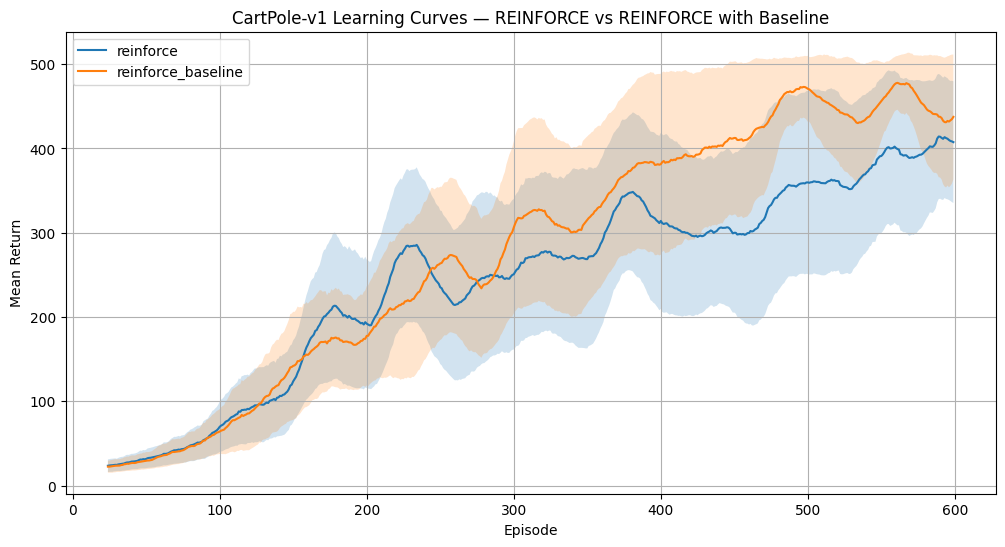

In [14]:
def plot_cartpole_learning_curves(experiments, window_size=25):
    plt.figure(figsize=(12, 6))

    for experiment in experiments:
        mean, ci = mean_and_95_ci(experiment["returns"])
        mean_smooth, ci_smooth, x = smooth_mean_ci(mean, ci, window_size)

        label = experiment["algorithm_name"]

        plt.plot(x, mean_smooth, label=label)
        plt.fill_between(
            x,
            mean_smooth - ci_smooth,
            mean_smooth + ci_smooth,
            alpha=0.2
        )

    plt.title("CartPole-v1 Learning Curves — REINFORCE vs REINFORCE with Baseline")
    plt.xlabel("Episode")
    plt.ylabel("Mean Return")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_cartpole_learning_curves(
    [reinforce_results, reinforce_baseline_results],
    window_size=25
)

### Plotting Return Variance Across Seeds

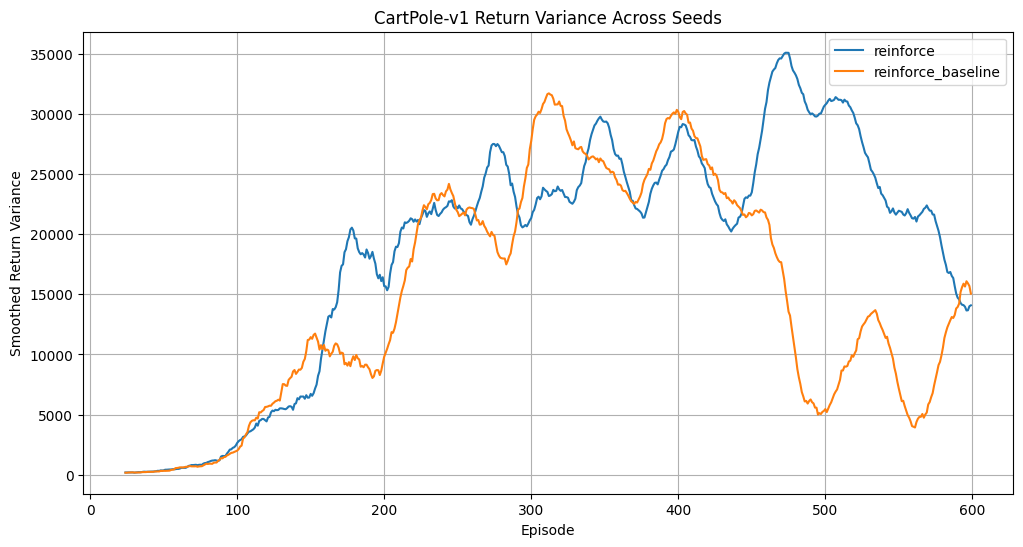

In [15]:
def plot_cartpole_return_variance(experiments, window_size=25):
    plt.figure(figsize=(12, 6))

    for experiment in experiments:
        returns = experiment["returns"]
        variance = np.var(returns, axis=0, ddof=1)
        variance_smooth = moving_average(variance, window_size)

        x = np.arange(len(variance_smooth)) + window_size - 1

        plt.plot(x, variance_smooth, label=experiment["algorithm_name"])

    plt.title("CartPole-v1 Return Variance Across Seeds")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Return Variance")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_cartpole_return_variance(
    [reinforce_results, reinforce_baseline_results],
    window_size=25
)

### Plotting CartPole Policy Entropy

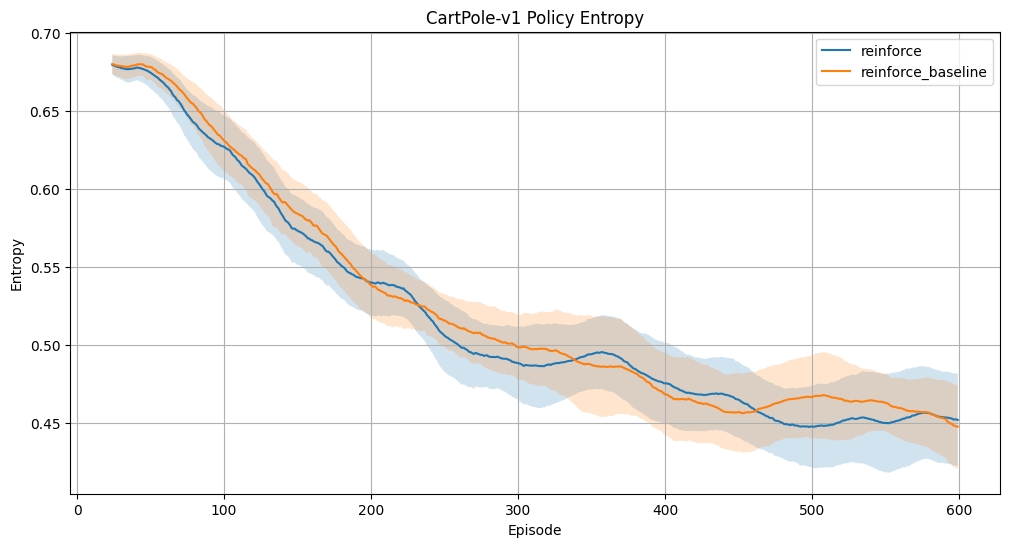

In [16]:
def plot_cartpole_entropy(experiments, window_size=25):
    plt.figure(figsize=(12, 6))

    for experiment in experiments:
        entropy_mean, entropy_ci = mean_and_95_ci(experiment["entropies"])
        entropy_smooth, entropy_ci_smooth, x = smooth_mean_ci(
            entropy_mean,
            entropy_ci,
            window_size
        )

        plt.plot(x, entropy_smooth, label=experiment["algorithm_name"])
        plt.fill_between(
            x,
            entropy_smooth - entropy_ci_smooth,
            entropy_smooth + entropy_ci_smooth,
            alpha=0.2
        )

    plt.title("CartPole-v1 Policy Entropy")
    plt.xlabel("Episode")
    plt.ylabel("Entropy")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_cartpole_entropy(
    [reinforce_results, reinforce_baseline_results],
    window_size=25
)

### Saving CartPole CheckPoints

In [17]:
best_reinforce_idx = int(np.argmax([np.mean(r["episode_returns"][-50:]) for r in reinforce_results["results"]]))
best_baseline_idx = int(np.argmax([np.mean(r["episode_returns"][-50:]) for r in reinforce_baseline_results["results"]]))

best_reinforce = reinforce_results["results"][best_reinforce_idx]
best_baseline = reinforce_baseline_results["results"][best_baseline_idx]

torch.save(
    best_reinforce["policy_net"].state_dict(),
    "checkpoints/cartpole_reinforce_policy.pt"
)

torch.save(
    best_baseline["policy_net"].state_dict(),
    "checkpoints/cartpole_reinforce_baseline_policy.pt"
)

torch.save(
    best_baseline["value_net"].state_dict(),
    "checkpoints/cartpole_reinforce_baseline_value.pt"
)

### Evaluating CartPole Policy

In [18]:
def evaluate_cartpole_policy(policy_net, num_episodes=20, seed=10_000):
    env = gym.make("CartPole-v1")

    returns = []
    lengths = []

    policy_net.eval()

    for episode in range(num_episodes):
        obs, info = env.reset(seed=seed + episode)

        total_reward = 0.0
        terminated = False
        truncated = False
        steps = 0

        while not (terminated or truncated):
            obs_tensor = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)

            with torch.no_grad():
                logits = policy_net(obs_tensor)
                action = int(torch.argmax(logits, dim=-1).item())

            obs, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            steps += 1

        returns.append(total_reward)
        lengths.append(steps)

    env.close()

    policy_net.train()

    return {
        "mean_return": np.mean(returns),
        "std_return": np.std(returns, ddof=1),
        "mean_length": np.mean(lengths),
        "returns": np.array(returns),
        "lengths": np.array(lengths)
    }


reinforce_eval = evaluate_cartpole_policy(best_reinforce["policy_net"])
baseline_eval = evaluate_cartpole_policy(best_baseline["policy_net"])

print("REINFORCE evaluation:", reinforce_eval)
print("REINFORCE with baseline evaluation:", baseline_eval)

REINFORCE evaluation: {'mean_return': np.float64(500.0), 'std_return': np.float64(0.0), 'mean_length': np.float64(500.0), 'returns': array([500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500.]), 'lengths': array([500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500,
       500, 500, 500, 500, 500, 500, 500])}
REINFORCE with baseline evaluation: {'mean_return': np.float64(500.0), 'std_return': np.float64(0.0), 'mean_length': np.float64(500.0), 'returns': array([500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500.]), 'lengths': array([500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500,
       500, 500, 500, 500, 500, 500, 500])}


### Actor Critic on Pendulum-v1

In [19]:
PENDULUM_ENV_NAME = "Pendulum-v1"

pend_env = gym.make(PENDULUM_ENV_NAME)

PENDULUM_OBS_DIM = pend_env.observation_space.shape[0]
PENDULUM_ACTION_DIM = pend_env.action_space.shape[0]
PENDULUM_ACTION_LOW = float(pend_env.action_space.low[0])
PENDULUM_ACTION_HIGH = float(pend_env.action_space.high[0])

print("Pendulum observation space:", pend_env.observation_space)
print("Pendulum action space:", pend_env.action_space)
print("Observation dimension:", PENDULUM_OBS_DIM)
print("Action dimension:", PENDULUM_ACTION_DIM)
print("Action low:", PENDULUM_ACTION_LOW)
print("Action high:", PENDULUM_ACTION_HIGH)

pend_env.close()

Pendulum observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Pendulum action space: Box(-2.0, 2.0, (1,), float32)
Observation dimension: 3
Action dimension: 1
Action low: -2.0
Action high: 2.0


### Continuous Actor Network

In [20]:
class GaussianActor(nn.Module):
    def __init__(
        self,
        obs_dim,
        action_dim,
        action_low,
        action_high,
        hidden_sizes=(128, 128),
        initial_log_std=-0.5
    ):
        super().__init__()

        self.action_dim = action_dim
        self.action_low = action_low
        self.action_high = action_high
        self.action_scale = (action_high - action_low) / 2.0
        self.action_mid = (action_high + action_low) / 2.0

        layers = []
        input_dim = obs_dim

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_dim, hidden_size))
            layers.append(nn.Tanh())
            input_dim = hidden_size

        self.body = nn.Sequential(*layers)

        self.mu_head = nn.Linear(input_dim, action_dim)
        self.log_std_head = nn.Linear(input_dim, action_dim)

        nn.init.constant_(self.log_std_head.bias, initial_log_std)

    def forward(self, obs):
        x = self.body(obs)

        raw_mu = self.mu_head(x)
        mu = torch.tanh(raw_mu) * self.action_scale + self.action_mid

        log_std = self.log_std_head(x)
        log_std = torch.clamp(log_std, min=-5.0, max=2.0)
        std = torch.exp(log_std)

        return mu, std, log_std

    def distribution(self, obs):
        mu, std, log_std = self.forward(obs)
        dist = Normal(mu, std)
        return dist, mu, std, log_std

### Continuous Critic Network

In [21]:
class StateValueCritic(nn.Module):
    def __init__(self, obs_dim, hidden_sizes=(128, 128)):
        super().__init__()

        layers = []
        input_dim = obs_dim

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_dim, hidden_size))
            layers.append(nn.Tanh())
            input_dim = hidden_size

        self.body = nn.Sequential(*layers)
        self.value_head = nn.Linear(input_dim, 1)

    def forward(self, obs):
        x = self.body(obs)
        value = self.value_head(x)
        return value.squeeze(-1)

### Actor Critic Configuration

In [22]:
@dataclass
class ActorCriticConfig:
    env_name: str = "Pendulum-v1"
    num_episodes: int = 500
    max_steps_per_episode: int = 200
    gamma: float = 0.99
    actor_lr: float = 3e-4
    critic_lr: float = 1e-3
    hidden_sizes: tuple = (128, 128)
    entropy_coef: float = 0.001
    initial_log_std: float = -0.5
    seed: int = 42

### Training Online Actor-Critic with TD(0)

In [23]:
def train_actor_critic(config):
    set_seed(config.seed)

    env = gym.make(config.env_name)

    obs_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]

    action_low = float(env.action_space.low[0])
    action_high = float(env.action_space.high[0])

    actor = GaussianActor(
        obs_dim=obs_dim,
        action_dim=action_dim,
        action_low=action_low,
        action_high=action_high,
        hidden_sizes=config.hidden_sizes,
        initial_log_std=config.initial_log_std
    ).to(DEVICE)

    critic = StateValueCritic(
        obs_dim=obs_dim,
        hidden_sizes=config.hidden_sizes
    ).to(DEVICE)

    actor_optimizer = optim.Adam(actor.parameters(), lr=config.actor_lr)
    critic_optimizer = optim.Adam(critic.parameters(), lr=config.critic_lr)

    episode_returns = np.zeros(config.num_episodes, dtype=np.float64)
    episode_lengths = np.zeros(config.num_episodes, dtype=np.int64)
    mean_td_errors = np.zeros(config.num_episodes, dtype=np.float64)
    mean_entropies = np.zeros(config.num_episodes, dtype=np.float64)
    actor_losses = np.zeros(config.num_episodes, dtype=np.float64)
    critic_losses = np.zeros(config.num_episodes, dtype=np.float64)

    for episode in range(config.num_episodes):
        obs, info = env.reset(seed=config.seed + episode)

        total_reward = 0.0
        td_errors = []
        entropies = []
        actor_loss_values = []
        critic_loss_values = []

        for step in range(config.max_steps_per_episode):
            obs_tensor = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)

            dist, mu, std, log_std = actor.distribution(obs_tensor)

            action_tensor = dist.sample()
            log_prob = dist.log_prob(action_tensor).sum(dim=-1)
            entropy = dist.entropy().sum(dim=-1)

            clipped_action_tensor = torch.clamp(
                action_tensor,
                min=action_low,
                max=action_high
            )

            action_np = clipped_action_tensor.detach().cpu().numpy()[0]

            next_obs, reward, terminated, truncated, info = env.step(action_np)

            next_obs_tensor = torch.tensor(
                next_obs,
                dtype=torch.float32,
                device=DEVICE
            ).unsqueeze(0)

            value = critic(obs_tensor)

            with torch.no_grad():
                if terminated:
                    next_value = torch.zeros_like(value)
                else:
                    next_value = critic(next_obs_tensor)

                target = torch.tensor(
                    [reward],
                    dtype=torch.float32,
                    device=DEVICE
                ) + config.gamma * next_value

            delta = target - value

            critic_loss = F.mse_loss(value, target)

            actor_loss = -(log_prob * delta.detach()) - config.entropy_coef * entropy
            actor_loss = actor_loss.mean()

            critic_optimizer.zero_grad()
            critic_loss.backward()
            critic_optimizer.step()

            actor_optimizer.zero_grad()
            actor_loss.backward()
            actor_optimizer.step()

            total_reward += reward
            td_errors.append(abs(float(delta.detach().cpu().item())))
            entropies.append(float(entropy.detach().cpu().item()))
            actor_loss_values.append(float(actor_loss.detach().cpu().item()))
            critic_loss_values.append(float(critic_loss.detach().cpu().item()))

            obs = next_obs

            if terminated or truncated:
                break

        episode_returns[episode] = total_reward
        episode_lengths[episode] = step + 1
        mean_td_errors[episode] = np.mean(td_errors)
        mean_entropies[episode] = np.mean(entropies)
        actor_losses[episode] = np.mean(actor_loss_values)
        critic_losses[episode] = np.mean(critic_loss_values)

        if (episode + 1) % 50 == 0:
            recent_return = np.mean(episode_returns[max(0, episode - 49): episode + 1])
            print(
                f"Episode {episode + 1:4d} | "
                f"Recent Avg Return: {recent_return:8.2f} | "
                f"Entropy: {mean_entropies[episode]:.4f} | "
                f"TD Error: {mean_td_errors[episode]:.4f}"
            )

    env.close()

    return {
        "actor": actor,
        "critic": critic,
        "episode_returns": episode_returns,
        "episode_lengths": episode_lengths,
        "mean_td_errors": mean_td_errors,
        "mean_entropies": mean_entropies,
        "actor_losses": actor_losses,
        "critic_losses": critic_losses,
        "config": config
    }

### Training the model on Pendulum-v1

In [24]:
ac_config = ActorCriticConfig(
    env_name="Pendulum-v1",
    num_episodes=500,
    max_steps_per_episode=200,
    gamma=0.99,
    actor_lr=3e-4,
    critic_lr=1e-3,
    hidden_sizes=(128, 128),
    entropy_coef=0.001,
    initial_log_std=-0.5,
    seed=42
)

actor_critic_result = train_actor_critic(ac_config)

Episode   50 | Recent Avg Return: -1511.10 | Entropy: -1.1917 | TD Error: 2.1136
Episode  100 | Recent Avg Return: -1513.64 | Entropy: 2.7243 | TD Error: 3.0251
Episode  150 | Recent Avg Return: -1417.62 | Entropy: -2.5769 | TD Error: 2.6421
Episode  200 | Recent Avg Return: -1517.48 | Entropy: -3.0720 | TD Error: 1.5314
Episode  250 | Recent Avg Return: -1441.14 | Entropy: 3.0101 | TD Error: 7.2019
Episode  300 | Recent Avg Return: -1509.04 | Entropy: -2.3358 | TD Error: 4.3346
Episode  350 | Recent Avg Return: -1543.20 | Entropy: -2.7859 | TD Error: 3.2821
Episode  400 | Recent Avg Return: -1574.24 | Entropy: -3.5072 | TD Error: 2.6582
Episode  450 | Recent Avg Return: -1398.58 | Entropy: 2.0191 | TD Error: 5.9042
Episode  500 | Recent Avg Return: -1403.66 | Entropy: 0.6106 | TD Error: 4.6680


### Plotting Actor Critic Return Per Episode

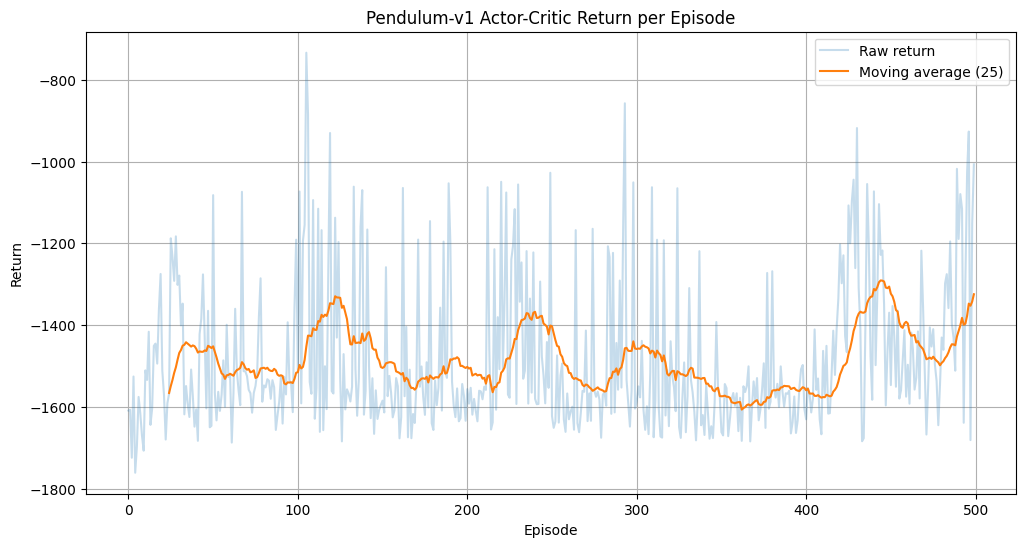

In [25]:
def plot_actor_critic_returns(result, window_size=25):
    returns = result["episode_returns"]
    smoothed = moving_average(returns, window_size)

    plt.figure(figsize=(12, 6))
    plt.plot(returns, alpha=0.25, label="Raw return")
    plt.plot(
        np.arange(len(smoothed)) + window_size - 1,
        smoothed,
        label=f"Moving average ({window_size})"
    )

    plt.title("Pendulum-v1 Actor-Critic Return per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_actor_critic_returns(actor_critic_result, window_size=25)

### Plotting Policy Entropy Over Time

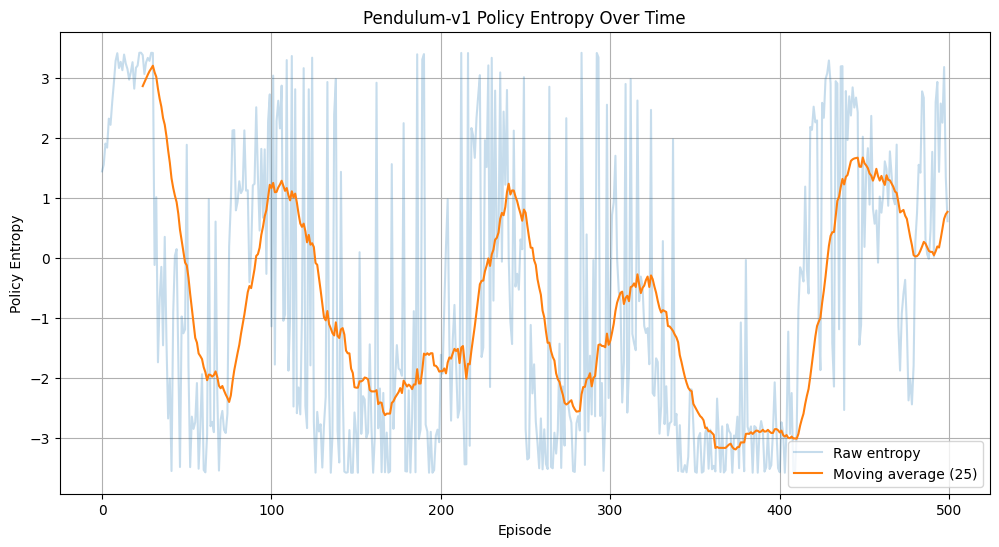

In [26]:
def plot_actor_critic_entropy(result, window_size=25):
    entropies = result["mean_entropies"]
    smoothed = moving_average(entropies, window_size)

    plt.figure(figsize=(12, 6))
    plt.plot(entropies, alpha=0.25, label="Raw entropy")
    plt.plot(
        np.arange(len(smoothed)) + window_size - 1,
        smoothed,
        label=f"Moving average ({window_size})"
    )

    plt.title("Pendulum-v1 Policy Entropy Over Time")
    plt.xlabel("Episode")
    plt.ylabel("Policy Entropy")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_actor_critic_entropy(actor_critic_result, window_size=25)

### Plotting TD Error Magnitude Over Training

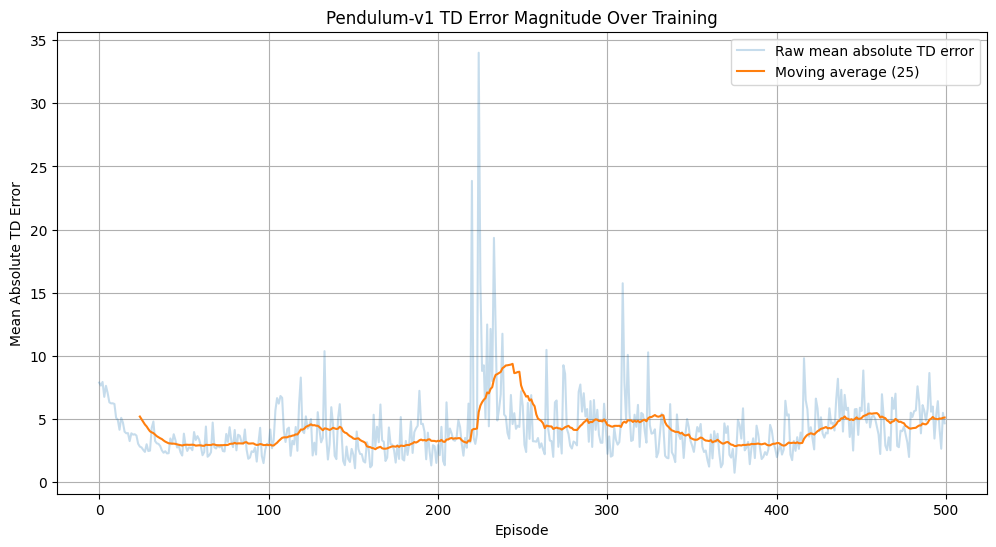

In [27]:
def plot_actor_critic_td_errors(result, window_size=25):
    td_errors = result["mean_td_errors"]
    smoothed = moving_average(td_errors, window_size)

    plt.figure(figsize=(12, 6))
    plt.plot(td_errors, alpha=0.25, label="Raw mean absolute TD error")
    plt.plot(
        np.arange(len(smoothed)) + window_size - 1,
        smoothed,
        label=f"Moving average ({window_size})"
    )

    plt.title("Pendulum-v1 TD Error Magnitude Over Training")
    plt.xlabel("Episode")
    plt.ylabel("Mean Absolute TD Error")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_actor_critic_td_errors(actor_critic_result, window_size=25)

### Plotting Actor and Critic Losses

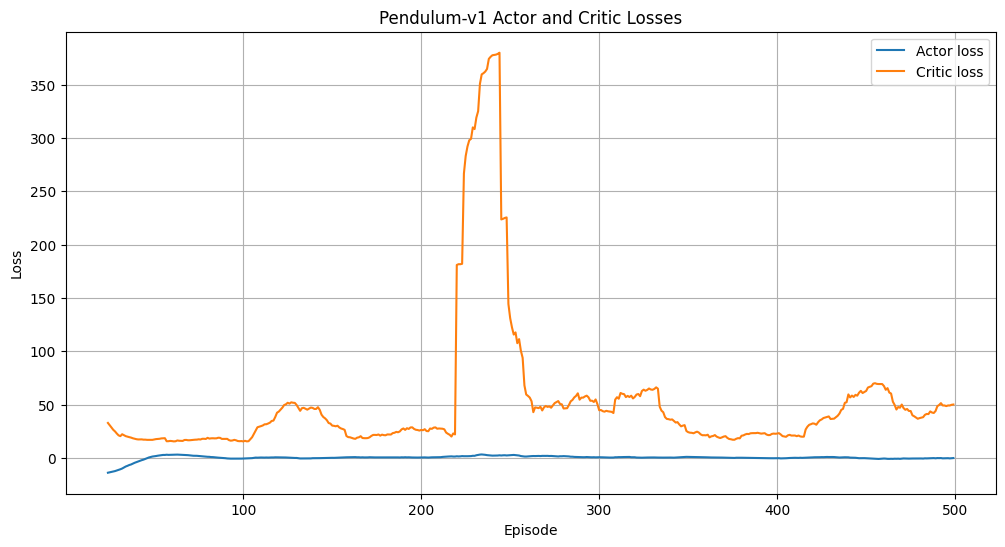

In [28]:
def plot_actor_critic_losses(result, window_size=25):
    actor_losses = result["actor_losses"]
    critic_losses = result["critic_losses"]

    actor_smooth = moving_average(actor_losses, window_size)
    critic_smooth = moving_average(critic_losses, window_size)

    x_actor = np.arange(len(actor_smooth)) + window_size - 1
    x_critic = np.arange(len(critic_smooth)) + window_size - 1

    plt.figure(figsize=(12, 6))
    plt.plot(x_actor, actor_smooth, label="Actor loss")
    plt.plot(x_critic, critic_smooth, label="Critic loss")
    plt.title("Pendulum-v1 Actor and Critic Losses")
    plt.xlabel("Episode")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_actor_critic_losses(actor_critic_result, window_size=25)

### Evaluating Greedy Mean Policy on Pendulum-v1

In [29]:
def evaluate_pendulum_actor(actor, num_episodes=20, seed=20_000):
    env = gym.make("Pendulum-v1")

    returns = []
    lengths = []

    actor.eval()

    for episode in range(num_episodes):
        obs, info = env.reset(seed=seed + episode)

        total_reward = 0.0

        for step in range(200):
            obs_tensor = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)

            with torch.no_grad():
                mu, std, log_std = actor(obs_tensor)
                action = torch.clamp(
                    mu,
                    min=float(env.action_space.low[0]),
                    max=float(env.action_space.high[0])
                )

            action_np = action.cpu().numpy()[0]

            obs, reward, terminated, truncated, info = env.step(action_np)

            total_reward += reward

            if terminated or truncated:
                break

        returns.append(total_reward)
        lengths.append(step + 1)

    env.close()

    actor.train()

    return {
        "mean_return": np.mean(returns),
        "std_return": np.std(returns, ddof=1),
        "mean_length": np.mean(lengths),
        "returns": np.array(returns),
        "lengths": np.array(lengths)
    }


pendulum_eval = evaluate_pendulum_actor(actor_critic_result["actor"])

print("Pendulum Actor-Critic evaluation:", pendulum_eval)

Pendulum Actor-Critic evaluation: {'mean_return': np.float64(-1405.6673542608478), 'std_return': np.float64(201.99098667066363), 'mean_length': np.float64(200.0), 'returns': array([-1480.4899726 , -1497.28533411, -1464.36549998,  -995.73384266,
       -1152.83703347, -1561.84205586, -1465.64098806, -1483.96714655,
       -1499.91312856,  -962.15921698, -1194.62121751, -1513.60244696,
       -1504.73603616, -1504.14303621, -1488.23702795, -1087.66346727,
       -1587.35370732, -1577.64603027, -1564.66027779, -1526.44961895]), 'lengths': array([200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
       200, 200, 200, 200, 200, 200, 200])}


### Generate Sample Pendulum Trajectory

In [30]:
def generate_pendulum_trajectory(actor, seed=30_000, max_steps=200):
    env = gym.make("Pendulum-v1")

    obs, info = env.reset(seed=seed)

    observations = []
    actions = []
    rewards = []

    actor.eval()

    for step in range(max_steps):
        obs_tensor = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)

        with torch.no_grad():
            mu, std, log_std = actor(obs_tensor)
            action = torch.clamp(
                mu,
                min=float(env.action_space.low[0]),
                max=float(env.action_space.high[0])
            )

        action_np = action.cpu().numpy()[0]

        next_obs, reward, terminated, truncated, info = env.step(action_np)

        observations.append(obs)
        actions.append(action_np[0])
        rewards.append(reward)

        obs = next_obs

        if terminated or truncated:
            break

    env.close()

    actor.train()

    observations = np.array(observations)
    actions = np.array(actions)
    rewards = np.array(rewards)

    theta = np.arctan2(observations[:, 1], observations[:, 0])
    theta_dot = observations[:, 2]

    return {
        "observations": observations,
        "theta": theta,
        "theta_dot": theta_dot,
        "actions": actions,
        "rewards": rewards,
        "return": np.sum(rewards)
    }

### Plotting Sample Trajectory from Learned Pendulum Policy

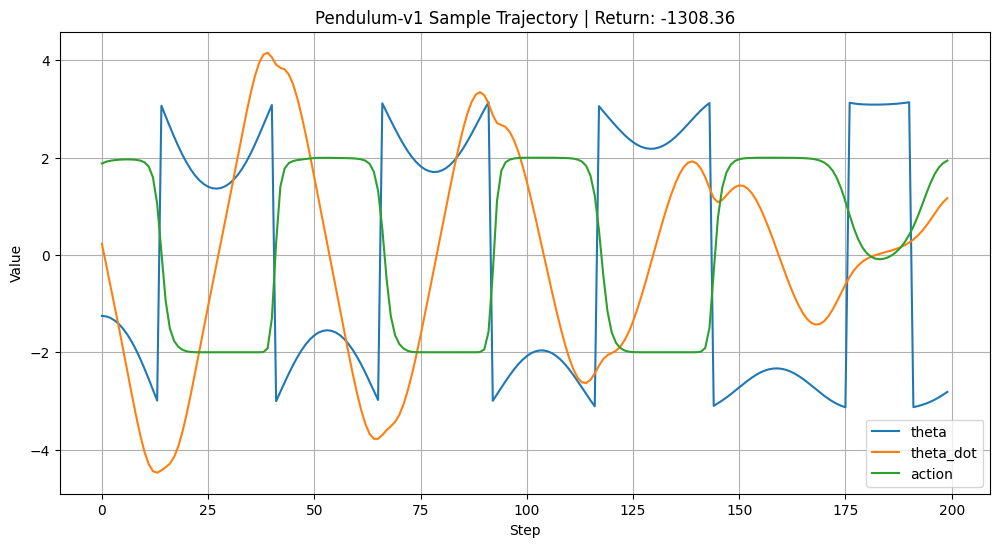

In [31]:
def plot_pendulum_sample_trajectory(actor):
    trajectory = generate_pendulum_trajectory(actor)

    t = np.arange(len(trajectory["rewards"]))

    plt.figure(figsize=(12, 6))
    plt.plot(t, trajectory["theta"], label="theta")
    plt.plot(t, trajectory["theta_dot"], label="theta_dot")
    plt.plot(t, trajectory["actions"], label="action")
    plt.title(f"Pendulum-v1 Sample Trajectory | Return: {trajectory['return']:.2f}")
    plt.xlabel("Step")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_pendulum_sample_trajectory(actor_critic_result["actor"])

### Plotting Actor Mean Action Across Pendulum State Space

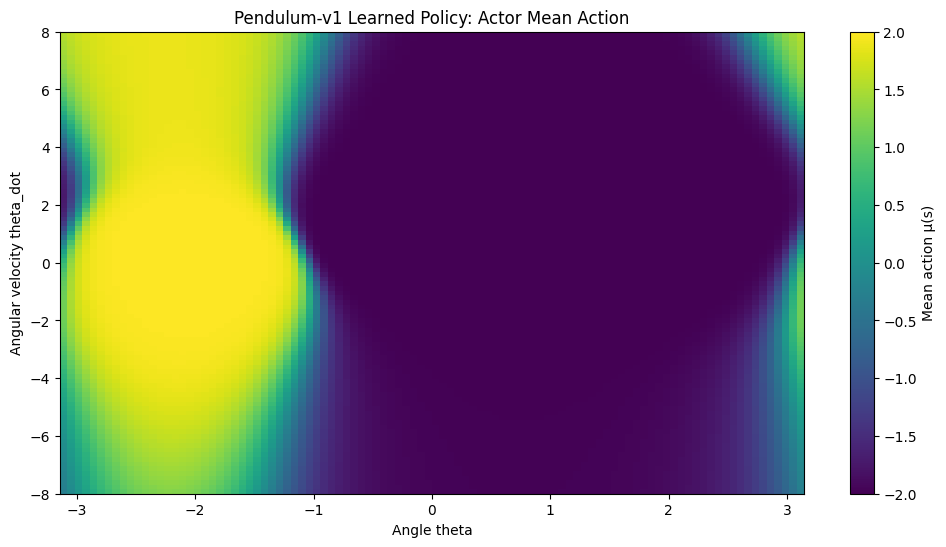

In [32]:
def plot_actor_mean_action_grid(actor, theta_points=100, theta_dot_points=100):
    theta_values = np.linspace(-np.pi, np.pi, theta_points)
    theta_dot_values = np.linspace(-8.0, 8.0, theta_dot_points)

    theta_grid, theta_dot_grid = np.meshgrid(theta_values, theta_dot_values)

    mean_action_grid = np.zeros_like(theta_grid, dtype=np.float64)

    actor.eval()

    for i in range(theta_grid.shape[0]):
        for j in range(theta_grid.shape[1]):
            theta = theta_grid[i, j]
            theta_dot = theta_dot_grid[i, j]

            obs = np.array(
                [np.cos(theta), np.sin(theta), theta_dot],
                dtype=np.float32
            )

            obs_tensor = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)

            with torch.no_grad():
                mu, std, log_std = actor(obs_tensor)

            mean_action_grid[i, j] = float(mu.cpu().numpy()[0, 0])

    actor.train()

    plt.figure(figsize=(12, 6))

    im = plt.imshow(
        mean_action_grid,
        origin="lower",
        aspect="auto",
        extent=[
            theta_values[0],
            theta_values[-1],
            theta_dot_values[0],
            theta_dot_values[-1]
        ],
        vmin=-2.0,
        vmax=2.0
    )

    plt.title("Pendulum-v1 Learned Policy: Actor Mean Action")
    plt.xlabel("Angle theta")
    plt.ylabel("Angular velocity theta_dot")
    plt.colorbar(im, label="Mean action μ(s)")
    plt.grid(False)
    plt.show()


plot_actor_mean_action_grid(actor_critic_result["actor"])

### Plotting Sample Trajectories Over Actor Mean Action Space

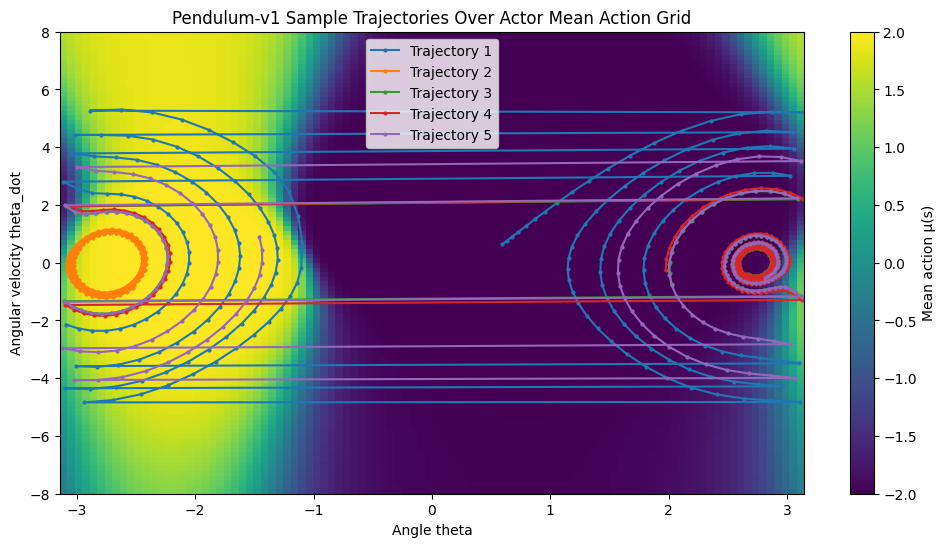

In [33]:
def plot_pendulum_trajectories_on_policy(actor, num_trajectories=5):
    theta_values = np.linspace(-np.pi, np.pi, 100)
    theta_dot_values = np.linspace(-8.0, 8.0, 100)

    theta_grid, theta_dot_grid = np.meshgrid(theta_values, theta_dot_values)
    mean_action_grid = np.zeros_like(theta_grid, dtype=np.float64)

    actor.eval()

    for i in range(theta_grid.shape[0]):
        for j in range(theta_grid.shape[1]):
            theta = theta_grid[i, j]
            theta_dot = theta_dot_grid[i, j]

            obs = np.array(
                [np.cos(theta), np.sin(theta), theta_dot],
                dtype=np.float32
            )

            obs_tensor = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)

            with torch.no_grad():
                mu, std, log_std = actor(obs_tensor)

            mean_action_grid[i, j] = float(mu.cpu().numpy()[0, 0])

    plt.figure(figsize=(12, 6))

    im = plt.imshow(
        mean_action_grid,
        origin="lower",
        aspect="auto",
        extent=[
            theta_values[0],
            theta_values[-1],
            theta_dot_values[0],
            theta_dot_values[-1]
        ],
        vmin=-2.0,
        vmax=2.0
    )

    for idx in range(num_trajectories):
        traj = generate_pendulum_trajectory(
            actor,
            seed=40_000 + idx,
            max_steps=200
        )

        plt.plot(
            traj["theta"],
            traj["theta_dot"],
            linewidth=1.5,
            marker="o",
            markersize=2,
            label=f"Trajectory {idx + 1}"
        )

    actor.train()

    plt.title("Pendulum-v1 Sample Trajectories Over Actor Mean Action Grid")
    plt.xlabel("Angle theta")
    plt.ylabel("Angular velocity theta_dot")
    plt.colorbar(im, label="Mean action μ(s)")
    plt.legend()
    plt.grid(False)
    plt.show()


plot_pendulum_trajectories_on_policy(actor_critic_result["actor"], num_trajectories=5)

### Saving Pendulum Actor Critic Checkpoints

In [34]:
torch.save(
    actor_critic_result["actor"].state_dict(),
    "checkpoints/pendulum_actor_critic_actor.pt"
)

torch.save(
    actor_critic_result["critic"].state_dict(),
    "checkpoints/pendulum_actor_critic_critic.pt"
)

### Hyperparameter Summary

In [ ]:
hyperparameter_summary = {
    "CartPole REINFORCE policy network": "(128, 128), ReLU",
    "CartPole baseline value network": "(128, 128), ReLU",
    "CartPole gamma": 0.99,
    "CartPole policy learning rate": 1e-3,
    "CartPole value learning rate": 1e-3,
    "CartPole optimizer": "Adam",
    "Pendulum actor network": "(128, 128), Tanh",
    "Pendulum critic network": "(128, 128), Tanh",
    "Pendulum gamma": 0.99,
    "Pendulum actor learning rate": 3e-4,
    "Pendulum critic learning rate": 1e-3,
    "Pendulum entropy coefficient": 0.001,
    "Pendulum initial log std": -0.5,
    "Pendulum optimizer": "Adam"
}

#hyperparameter_summary

{'CartPole REINFORCE policy network': '(128, 128), ReLU',
 'CartPole baseline value network': '(128, 128), ReLU',
 'CartPole gamma': 0.99,
 'CartPole policy learning rate': 0.001,
 'CartPole value learning rate': 0.001,
 'CartPole optimizer': 'Adam',
 'Pendulum actor network': '(128, 128), Tanh',
 'Pendulum critic network': '(128, 128), Tanh',
 'Pendulum gamma': 0.99,
 'Pendulum actor learning rate': 0.0003,
 'Pendulum critic learning rate': 0.001,
 'Pendulum entropy coefficient': 0.001,
 'Pendulum initial log std': -0.5,
 'Pendulum optimizer': 'Adam'}

### Comparison Table for CartPole Experiments

In [ ]:
def summarize_cartpole_experiment(experiment, final_window=50):
    returns = experiment["returns"]

    final_returns = returns[:, -final_window:]

    return {
        "Algorithm": experiment["algorithm_name"],
        "Mean Final Return": np.mean(final_returns),
        "Std Final Return": np.std(final_returns, ddof=1),
        "Mean Return Variance Across Training": np.mean(np.var(returns, axis=0, ddof=1)),
        "Best Seed Final Return": np.max(np.mean(final_returns, axis=1)),
        "Worst Seed Final Return": np.min(np.mean(final_returns, axis=1))
    }


cartpole_summary = [
    summarize_cartpole_experiment(reinforce_results),
    summarize_cartpole_experiment(reinforce_baseline_results)
]


[{'Algorithm': 'reinforce',
  'Mean Final Return': np.float64(398.992),
  'Std Final Return': np.float64(131.11410967363898),
  'Mean Return Variance Across Training': np.float64(18440.30698148148),
  'Best Seed Final Return': np.float64(497.48),
  'Worst Seed Final Return': np.float64(212.46)},
 {'Algorithm': 'reinforce_baseline',
  'Mean Final Return': np.float64(450.398),
  'Std Final Return': np.float64(104.59140653343029),
  'Mean Return Variance Across Training': np.float64(14410.225555555557),
  'Best Seed Final Return': np.float64(500.0),
  'Worst Seed Final Return': np.float64(315.36)}]

### Saving the Comparison Table

In [37]:
import pandas as pd
pd.DataFrame(cartpole_summary).to_csv("cartpole_policy_gradient_summary.csv",index=False)
pd.DataFrame([hyperparameter_summary]).to_csv("policy_gradient_hyperparameter_summary.csv", index=False)

In [39]:
pd.DataFrame(cartpole_summary)

,Algorithm,Mean Final Return,Std Final Return,Mean Return Variance Across Training,Best Seed Final Return,Worst Seed Final Return
0,reinforce,398.992,131.114110,18440.306981,497.48,212.46
1,reinforce_baseline,450.398,104.591407,14410.225556,500.00,315.36
